# Mühendisler İçin Olasılık
# Bölüm 7 — Beklenen Değerin Özellikleri
---

Bu notebook aşağıdaki konuları **teori → kod → görselleştirme → yorum** akışıyla ele almaktadır:

| # | Konu |
|---|------|
| 1 | g(X,Y)'nin Beklenen Değeri |
| 2 | Toplam Beklenen Değeri — E[X+Y] = E[X]+E[Y] |
| 3 | Çarpım Beklenen Değeri — E[XY] ve Bağımsızlık |
| 4 | Kovaryans ve Özellikleri |
| 5 | Korelasyon |
| 6 | Koşullu Beklenen Değer ve İterasyon Yasası |
| 7 | Koşullu Varyans |
| 8 | Moment Üreten Fonksiyonlar (MÜF) |

In [1]:
# ── Gerekli kütüphaneler ──────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from itertools import product as iproduct

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
print("Kütüphaneler yüklendi ✓")

Kütüphaneler yüklendi ✓


---
## 1 · g(X, Y)'nin Beklenen Değeri

### Teori

$g(X,Y)$, $X$ ve $Y$ üzerinde tanımlı gerçel değerli bir fonksiyon olsun.

$$
E[g(X,Y)] = \begin{cases}
\displaystyle\sum_{x}\sum_{y} g(x,y)\,f(x,y) & \text{ayrık durum} \\
\displaystyle\int_{-\infty}^{\infty}\int_{-\infty}^{\infty} g(x,y)\,f(x,y)\,dx\,dy & \text{sürekli durum}
\end{cases}
$$

In [2]:
# ── Örnek: Ayrık Birleşik Dağılım ────────────────────────────────────────────
# X ∈ {1,2,3}, Y ∈ {1,2}  →  birleşik olasılık tablosu

x_vals = np.array([1, 2, 3])
y_vals = np.array([1, 2])

# f(x,y) : satır=x, sütun=y
f_xy = np.array([
    [0.10, 0.15],  # x=1
    [0.20, 0.25],  # x=2
    [0.15, 0.15],  # x=3
])

assert np.isclose(f_xy.sum(), 1.0), "Olasılık toplamı 1 olmalı!"

# g(x,y) = x^2 + y  seçelim
def g(x, y):
    return x**2 + y

# E[g(X,Y)] = Σ_x Σ_y g(x,y) * f(x,y)
E_g = sum(
    g(x_vals[i], y_vals[j]) * f_xy[i, j]
    for i in range(len(x_vals))
    for j in range(len(y_vals))
)

print("Birleşik olasılık tablosu f(x,y):")
print(f"{'':>6}", end="")
for y in y_vals:
    print(f"  Y={y}  ", end="")
print()
for i, x in enumerate(x_vals):
    print(f"X={x}  ", end="")
    for j in range(len(y_vals)):
        print(f"  {f_xy[i,j]:.2f}  ", end="")
    print()

print(f"\ng(x,y) = x² + y için E[g(X,Y)] = {E_g:.4f}")

Birleşik olasılık tablosu f(x,y):
        Y=1    Y=2  
X=1    0.10    0.15  
X=2    0.20    0.25  
X=3    0.15    0.15  

g(x,y) = x² + y için E[g(X,Y)] = 6.3000


---
## 2 · Toplam Beklenen Değeri: E[X + Y] = E[X] + E[Y]

### Teori

Bu özellik $X$ ve $Y$'nin **bağımsız olmasını gerektirmez** ve $n$ değişkene genelleşir:

$$E[X_1 + X_2 + \cdots + X_n] = E[X_1] + E[X_2] + \cdots + E[X_n]$$

**İspat özeti (sürekli durum):**

$$E(X+Y) = \iint (x+y)f(x,y)\,dx\,dy = \int x f_X(x)\,dx + \int y f_Y(y)\,dy = E(X)+E(Y)$$

In [3]:
# ── Sayısal doğrulama: Monte Carlo ile E[X+Y] = E[X] + E[Y] ─────────────────
N = 500_000

# X ~ Normal(μ=3, σ=1),  Y ~ Exponential(λ=0.5)  — BAĞIMLI olmayan iki değişken
X = np.random.normal(loc=3, scale=1, size=N)
Y = np.random.exponential(scale=2, size=N)   # E[Y] = 2

E_X   = X.mean()
E_Y   = Y.mean()
E_XpY = (X + Y).mean()

print("═" * 45)
print(f"  E[X]          = {E_X:.4f}  (teorik: 3.0000)")
print(f"  E[Y]          = {E_Y:.4f}  (teorik: 2.0000)")
print(f"  E[X] + E[Y]   = {E_X + E_Y:.4f}  (teorik: 5.0000)")
print(f"  E[X + Y]      = {E_XpY:.4f}")
print(f"  Fark          = {abs(E_XpY - (E_X + E_Y)):.6f}")
print("═" * 45)
print("✓ E[X+Y] = E[X]+E[Y]  doğrulandı.")

═════════════════════════════════════════════
  E[X]          = 2.9988  (teorik: 3.0000)
  E[Y]          = 2.0036  (teorik: 2.0000)
  E[X] + E[Y]   = 5.0025  (teorik: 5.0000)
  E[X + Y]      = 5.0025
  Fark          = 0.000000
═════════════════════════════════════════════
✓ E[X+Y] = E[X]+E[Y]  doğrulandı.


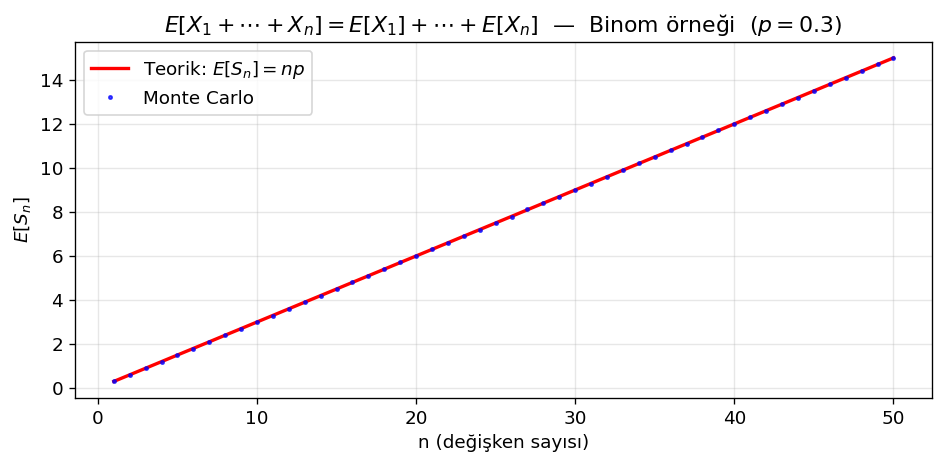

In [4]:
# ── Görselleştirme: n değişken toplamı ───────────────────────────────────────
# X_i ~ Bernoulli(p=0.3)  →  S_n = X_1+...+X_n ~ Binomial(n,p)
# E[S_n] = n*p  →  lineer artış

p = 0.3
n_values = np.arange(1, 51)
teorik_E = n_values * p

mc_E = [np.random.binomial(n, p, size=50_000).mean() for n in n_values]

plt.figure(figsize=(8, 4))
plt.plot(n_values, teorik_E, 'r-', lw=2, label=r'Teorik: $E[S_n] = np$')
plt.plot(n_values, mc_E, 'b.', ms=4, alpha=0.7, label='Monte Carlo')
plt.xlabel('n (değişken sayısı)')
plt.ylabel(r'$E[S_n]$')
plt.title(r'$E[X_1 + \cdots + X_n] = E[X_1] + \cdots + E[X_n]$  —  Binom örneği  ($p=0.3$)')
plt.legend()
plt.tight_layout()
plt.show()

---
## 3 · Çarpım Beklenen Değeri: E[XY]

### Teori

**Bağımsız** $X$ ve $Y$ için:

$$E[XY] = E[X]\,E[Y]$$

> ⚠️ Bu formül **yalnızca bağımsızlık durumunda** geçerlidir ve bağımsızlık için **yeterli bir koşul değildir**.

In [5]:
# ── Bağımsız durum: E[XY] = E[X]*E[Y] ────────────────────────────────────────
N = 500_000
X_ind = np.random.normal(2, 1, N)
Y_ind = np.random.normal(3, 1, N)   # X ⊥ Y

E_XY_bagımsız = (X_ind * Y_ind).mean()
E_X_E_Y       = X_ind.mean() * Y_ind.mean()

print("── Bağımsız X ve Y ──")
print(f"  E[XY]         = {E_XY_bagımsız:.4f}")
print(f"  E[X]·E[Y]     = {E_X_E_Y:.4f}")
print(f"  Eşit mi?       {'✓ Evet' if np.isclose(E_XY_bagımsız, E_X_E_Y, atol=0.02) else '✗ Hayır'}")

# ── Bağımlı durum: Y = 2X + ε ────────────────────────────────────────────────
X_dep = np.random.normal(0, 1, N)
Y_dep = 2 * X_dep + np.random.normal(0, 0.5, N)   # güçlü bağlılık

E_XY_bağımlı = (X_dep * Y_dep).mean()
E_X_E_Y_dep  = X_dep.mean() * Y_dep.mean()

print("\n── Bağımlı X ve Y  (Y = 2X + ε) ──")
print(f"  E[XY]         = {E_XY_bağımlı:.4f}")
print(f"  E[X]·E[Y]     = {E_X_E_Y_dep:.4f}")
print(f"  Eşit mi?       {'✓ Evet' if np.isclose(E_XY_bağımlı, E_X_E_Y_dep, atol=0.05) else '✗ Hayır — bağımlılık var!'}")

── Bağımsız X ve Y ──
  E[XY]         = 6.0016
  E[X]·E[Y]     = 6.0018
  Eşit mi?       ✓ Evet

── Bağımlı X ve Y  (Y = 2X + ε) ──
  E[XY]         = 2.0010
  E[X]·E[Y]     = 0.0000
  Eşit mi?       ✗ Hayır — bağımlılık var!


---
## 4 · Kovaryans

### Teori

$$\text{Cov}(X,Y) = E[(X-\mu_X)(Y-\mu_Y)] = E[XY] - \mu_X\mu_Y$$

**Temel özellikler:**

| Özellik | İfade |
|---------|-------|
| Simetri | $\text{Cov}(X,Y)=\text{Cov}(Y,X)$ |
| Sabit ile | $\text{Cov}(X,c)=0$ |
| Kendisi ile | $\text{Cov}(X,X)=\text{Var}(X)$ |
| Ölçekleme | $\text{Cov}(aX,bY)=ab\,\text{Cov}(X,Y)$ |
| Öteleme | $\text{Cov}(X+a,Y+b)=\text{Cov}(X,Y)$ |

**Toplam varyansı:**
$$\text{Var}(X+Y) = \text{Var}(X) + \text{Var}(Y) + 2\,\text{Cov}(X,Y)$$
$$\text{Var}(X-Y) = \text{Var}(X) + \text{Var}(Y) - 2\,\text{Cov}(X,Y)$$

In [6]:
# ── Kovaryans özelliklerinin sayısal doğrulaması ──────────────────────────────
N = 300_000
rng = np.random.default_rng(42)

X = rng.normal(4, 2, N)
Y = rng.normal(1, 3, N) + 0.6 * X   # bağımlı
a, b, c_const = 2.0, -3.0, 5.0

def cov(A, B):
    return np.mean((A - A.mean()) * (B - B.mean()))

print("Kovaryans Özellikleri — Sayısal Doğrulama")
print("═" * 50)

# Cov(X,Y) = Cov(Y,X)
print(f"Cov(X,Y)           = {cov(X,Y):+.4f}")
print(f"Cov(Y,X)           = {cov(Y,X):+.4f}  ← simetri ✓")

# Cov(X, sabit) = 0
C = np.full(N, c_const)
print(f"Cov(X, {c_const})         = {cov(X,C):+.6f}  ← ≈0 ✓")

# Cov(X,X) = Var(X)
print(f"Cov(X,X)           = {cov(X,X):+.4f}")
print(f"Var(X)             = {X.var():+.4f}  ← eşit ✓")

# Cov(aX, bY) = ab * Cov(X,Y)
lhs = cov(a*X, b*Y)
rhs = a * b * cov(X, Y)
print(f"Cov({a}X,{b}Y)       = {lhs:+.4f}")
print(f"ab·Cov(X,Y)        = {rhs:+.4f}  ← ölçekleme ✓")

# Cov(X+a, Y+b) = Cov(X,Y)
lhs2 = cov(X + a, Y + b)
print(f"Cov(X+{a}, Y+{b})   = {lhs2:+.4f}")
print(f"Cov(X,Y)           = {cov(X,Y):+.4f}  ← öteleme ✓")

# Var(X+Y) formülü
print("\nToplam Varyansı")
print(f"Var(X+Y) [direkt]  = {(X+Y).var():+.4f}")
print(f"Var(X)+Var(Y)+2Cov = {X.var()+Y.var()+2*cov(X,Y):+.4f}  ✓")

Kovaryans Özellikleri — Sayısal Doğrulama
══════════════════════════════════════════════════
Cov(X,Y)           = +2.3934
Cov(Y,X)           = +2.3934  ← simetri ✓
Cov(X, 5.0)         = +0.000000  ← ≈0 ✓
Cov(X,X)           = +4.0055
Var(X)             = +4.0055  ← eşit ✓
Cov(2.0X,-3.0Y)       = -14.3606
ab·Cov(X,Y)        = -14.3606  ← ölçekleme ✓
Cov(X+2.0, Y+-3.0)   = +2.3934
Cov(X,Y)           = +2.3934  ← öteleme ✓

Toplam Varyansı
Var(X+Y) [direkt]  = +19.2309
Var(X)+Var(Y)+2Cov = +19.2309  ✓


Karşıt Örnek: X ~ Uniform(-0.5, 0.5),  Y = X²
════════════════════════════════════════════════
  E[X]           = -0.000114  (teorik: 0)
  E[X³] = E[XY]  = -0.000040  (teorik: 0)
  Cov(X,Y)       = -0.000031  (teorik: 0)

  Y = X² olduğu için Y tamamen X'e bağlıdır.
  Ama Cov(X,Y) ≈ 0  →  Kovaryans bağımsızlığı garanti etmez!


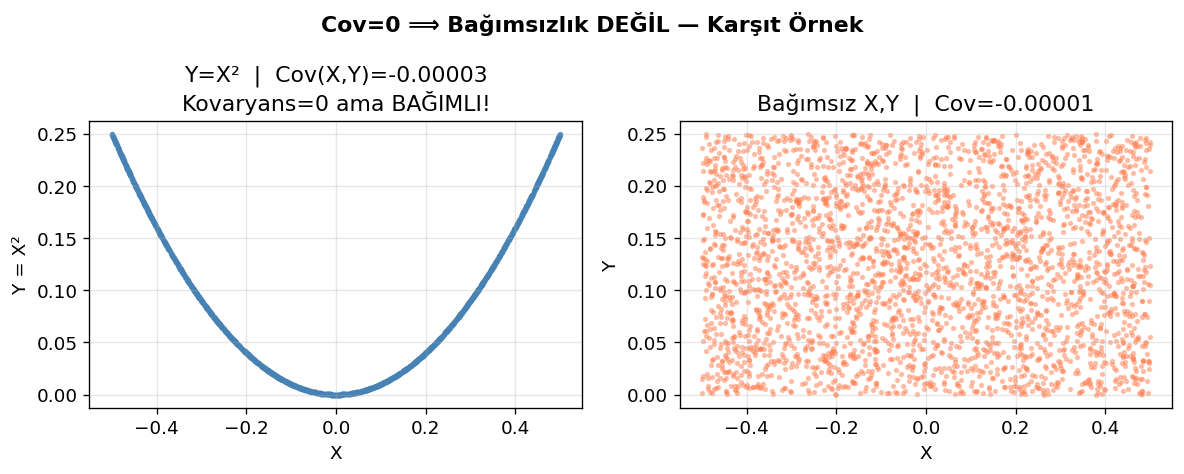

In [7]:
# ── Karşıt örnek: Cov=0 ⟹ Bağımsızlık DEĞİL ─────────────────────────────────
# Sunumdaki örnek: X ~ Uniform(-0.5, 0.5),  Y = X²

N = 500_000
X_u = np.random.uniform(-0.5, 0.5, N)
Y_u = X_u**2

cov_val = cov(X_u, Y_u)
E_X3    = np.mean(X_u**3)   # E[XY] = E[X³]

print("Karşıt Örnek: X ~ Uniform(-0.5, 0.5),  Y = X²")
print("═" * 48)
print(f"  E[X]           = {X_u.mean():+.6f}  (teorik: 0)")
print(f"  E[X³] = E[XY]  = {E_X3:+.6f}  (teorik: 0)")
print(f"  Cov(X,Y)       = {cov_val:+.6f}  (teorik: 0)")
print()
print("  Y = X² olduğu için Y tamamen X'e bağlıdır.")
print("  Ama Cov(X,Y) ≈ 0  →  Kovaryans bağımsızlığı garanti etmez!")

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
idx = np.random.choice(N, 3000)

axes[0].scatter(X_u[idx], Y_u[idx], s=5, alpha=0.4, color='steelblue')
axes[0].set_xlabel('X'); axes[0].set_ylabel('Y = X²')
axes[0].set_title(f'Y=X²  |  Cov(X,Y)={cov_val:.5f}\nKovaryans=0 ama BAĞIMLI!')

X_ind2 = np.random.uniform(-0.5, 0.5, N)
Y_ind2 = np.random.uniform(0, 0.25, N)
axes[1].scatter(X_ind2[idx], Y_ind2[idx], s=5, alpha=0.4, color='coral')
axes[1].set_xlabel('X'); axes[1].set_ylabel('Y')
axes[1].set_title(f'Bağımsız X,Y  |  Cov={cov(X_ind2,Y_ind2):.5f}')

plt.suptitle('Cov=0 ⟹ Bağımsızlık DEĞİL — Karşıt Örnek', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5 · Korelasyon

### Teori

Kovaryans, değişkenlerin ölçeğine bağlıdır. Ölçek-bağımsız ölçü:

$$\rho(X,Y) = \frac{\text{Cov}(X,Y)}{\sqrt{\text{Var}(X)}\,\sqrt{\text{Var}(Y)}}, \quad -1 \leq \rho \leq 1$$

- $|\rho|$ → doğrusal ilişkinin gücü  
- İşaret → pozitif / negatif ilişki  
- $\rho = 0$ → **ilişkisiz** (uncorrelated)

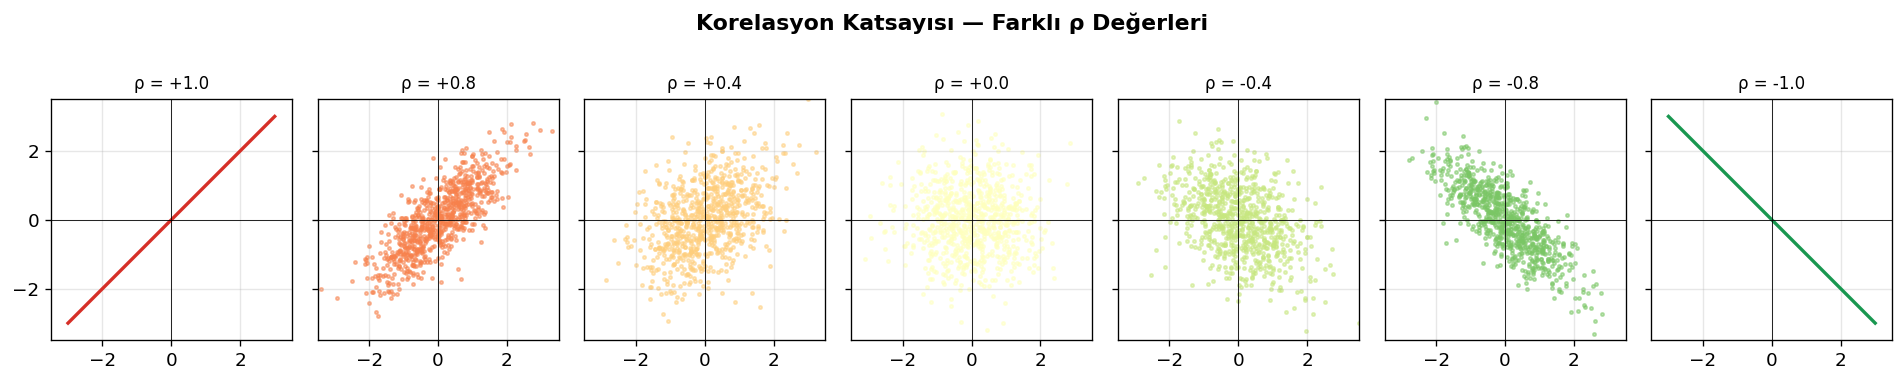

In [8]:
# ── Farklı korelasyon katsayılarının görselleştirilmesi ───────────────────────
def orneklem_uret(rho, n=800, seed=0):
    """Belirtilen korelasyona sahip (X,Y) çifti üretir."""
    rng = np.random.default_rng(seed)
    cov_mat = [[1, rho], [rho, 1]]
    return rng.multivariate_normal([0, 0], cov_mat, n).T

rho_values = [1.0, 0.8, 0.4, 0.0, -0.4, -0.8, -1.0]
colors     = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(rho_values)))

fig, axes = plt.subplots(1, len(rho_values), figsize=(16, 3), sharey=True)

for ax, rho, color in zip(axes, rho_values, colors):
    if abs(rho) == 1.0:
        x = np.linspace(-3, 3, 200)
        ax.plot(x, np.sign(rho) * x, color=color, lw=2)
    else:
        x, y = orneklem_uret(rho)
        ax.scatter(x, y, s=4, alpha=0.5, color=color)
    ax.set_title(f'ρ = {rho:+.1f}', fontsize=10)
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
    ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)

plt.suptitle('Korelasyon Katsayısı — Farklı ρ Değerleri', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# ── Korelasyon hesabı: Numpy ile doğrulama ───────────────────────────────────
def korelasyon(X, Y):
    """Pearson korelasyon katsayısı — manuel hesap."""
    return cov(X, Y) / (X.std() * Y.std())

print("Örnek korelasyon hesapları:")
print("─" * 40)
for rho_target in [0.9, 0.5, 0.0, -0.5, -0.9]:
    x, y = orneklem_uret(rho_target, n=100_000)
    rho_hat = korelasyon(x, y)
    print(f"  Hedef ρ={rho_target:+.1f}  →  Tahmin ρ̂={rho_hat:+.4f}")

Örnek korelasyon hesapları:
────────────────────────────────────────
  Hedef ρ=+0.9  →  Tahmin ρ̂=+0.9004
  Hedef ρ=+0.5  →  Tahmin ρ̂=+0.5014
  Hedef ρ=+0.0  →  Tahmin ρ̂=-0.0058
  Hedef ρ=-0.5  →  Tahmin ρ̂=-0.5014
  Hedef ρ=-0.9  →  Tahmin ρ̂=-0.9004


---
## 6 · Koşullu Beklenen Değer

### Teori

$$E[X \mid Y=y] = \begin{cases}
\displaystyle\sum_x x\, p_{X|Y}(x\mid y) & \text{ayrık} \\
\displaystyle\int_{-\infty}^{\infty} x\, f_{X|Y}(x\mid y)\,dx & \text{sürekli}
\end{cases}$$

### İterasyon Yasası (Tower Property)

$$\boxed{E[X] = E\bigl[E[X\mid Y]\bigr]}$$

Ayrık: $E[X] = \sum_y E[X \mid Y=y]\,P\{Y=y\}$  
Sürekli: $E[X] = \int E[X \mid Y=y]\,f_Y(y)\,dy$

Madenci Problemi — Koşullandırarak Beklenen Değer
════════════════════════════════════════════════
  Analitik çözüm:  E[X] = 15 saat
  Monte Carlo:     E[X] = 15.030 saat
  Standart sapma:  σ    = 14.863 saat


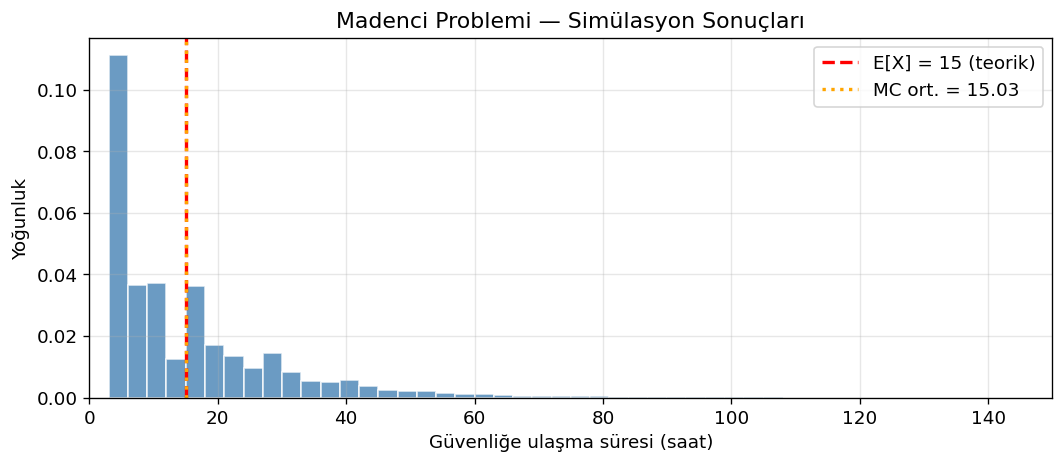

In [10]:
# ── Madenci Problemi (Sunumdaki örnek) ───────────────────────────────────────
# Kapı 1: 3 saat → güvenlik
# Kapı 2: 5 saat → geri döner
# Kapı 3: 7 saat → geri döner
# E[X] = ? (güvenliğe ulaşma süresi)

# Analitik çözüm:
# E[X] = (1/3)(3 + (5+E[X]) + (7+E[X]))
# E[X] = (1/3)(15 + 2*E[X])
# 3*E[X] = 15 + 2*E[X]  →  E[X] = 15

def madenci_simulasyon(n_sim=100_000):
    süreler = []
    for _ in range(n_sim):
        toplam = 0
        while True:
            kapi = np.random.choice([1, 2, 3])
            if kapi == 1:
                toplam += 3
                break          # güvenliğe ulaştı
            elif kapi == 2:
                toplam += 5    # madene geri döner
            else:
                toplam += 7    # madene geri döner
        süreler.append(toplam)
    return np.array(süreler)

süreler = madenci_simulasyon()

print("Madenci Problemi — Koşullandırarak Beklenen Değer")
print("═" * 48)
print(f"  Analitik çözüm:  E[X] = 15 saat")
print(f"  Monte Carlo:     E[X] = {süreler.mean():.3f} saat")
print(f"  Standart sapma:  σ    = {süreler.std():.3f} saat")

# Histogram
plt.figure(figsize=(9, 4))
plt.hist(süreler, bins=range(0, 200, 3), density=True,
         color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(15, color='red', lw=2, linestyle='--', label='E[X] = 15 (teorik)')
plt.axvline(süreler.mean(), color='orange', lw=2, linestyle=':', label=f'MC ort. = {süreler.mean():.2f}')
plt.xlabel('Güvenliğe ulaşma süresi (saat)')
plt.ylabel('Yoğunluk')
plt.title('Madenci Problemi — Simülasyon Sonuçları')
plt.legend()
plt.xlim(0, 150)
plt.tight_layout()
plt.show()

In [11]:
# ── İterasyon Yasasının sayısal doğrulaması ───────────────────────────────────
# Y ~ Poisson(λ=4)  — sınıftaki öğrenci sayısı
# X | Y=y ~ Normal(y, 1)  — ortalama not

N = 500_000
lam = 4
Y_pois = np.random.poisson(lam, N)          # Y ~ Poisson(4)
X_kos  = np.random.normal(Y_pois, 1)        # X|Y ~ Normal(Y, 1)

# Doğrudan E[X]
E_X_direkt = X_kos.mean()

# İterasyon: E[E[X|Y]] = Σ_y E[X|Y=y] * P(Y=y)
# E[X|Y=y] = y  (normal dağılımın ortalaması)
# E[E[X|Y]] = E[Y] = λ = 4
E_EXY = np.mean(Y_pois.astype(float))   # E[X|Y] = Y olduğundan

print("İterasyon Yasası: E[X] = E[E[X|Y]]")
print("═" * 44)
print(f"  Model: Y~Poisson(4),  X|Y~Normal(Y,1)")
print(f"  Teorik E[X]    = 4.0000  (= E[Y] = λ)")
print(f"  E[X] direkt    = {E_X_direkt:.4f}")
print(f"  E[E[X|Y]]      = {E_EXY:.4f}")
print(f"  Eşit mi?       {'✓ Evet' if np.isclose(E_X_direkt, E_EXY, atol=0.02) else '✗ Hayır'}")

İterasyon Yasası: E[X] = E[E[X|Y]]
════════════════════════════════════════════
  Model: Y~Poisson(4),  X|Y~Normal(Y,1)
  Teorik E[X]    = 4.0000  (= E[Y] = λ)
  E[X] direkt    = 3.9999
  E[E[X|Y]]      = 3.9980
  Eşit mi?       ✓ Evet


---
## 7 · Koşullu Varyans

### Teori

$$\text{Var}(X \mid Y=y) = E\bigl[(X - E[X \mid Y=y])^2 \mid Y=y\bigr]$$

**Eve-Adam Formülü (Law of Total Variance):**

$$\boxed{\text{Var}(X) = E[\text{Var}(X\mid Y)] + \text{Var}(E[X\mid Y])}$$

- $E[\text{Var}(X\mid Y)]$ → grup içi varyansın ortalaması  
- $\text{Var}(E[X\mid Y])$ → grup ortalamalarının varyansı

Toplam Varyans Yasası: Var(X) = E[Var(X|Y)] + Var(E[X|Y])
════════════════════════════════════════════════════
  Var(X) [direkt]          = 71.2780
  E[Var(X|Y)]  (grup içi)  = 4.6662
  Var(E[X|Y])  (gruplar arası) = 66.6187
  Toplam                   = 71.2849
  Eşit mi?  ✓ Evet


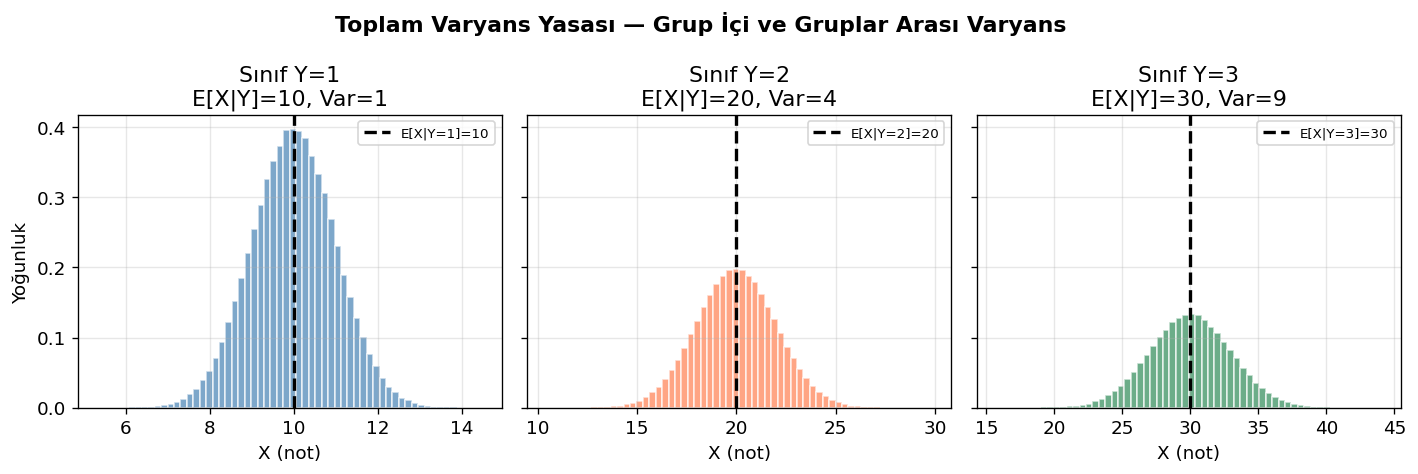

In [12]:
# ── Toplam Varyans Yasası — Sayısal Doğrulama ────────────────────────────────
# Sınıf örneği:
#   Y ~ Uniform{1,2,3}  →  hangi sınıf
#   X | Y=y ~ Normal(10*y, y)  →  sınava göre farklı ortalama ve std

N = 1_000_000
Y_sinif = np.random.choice([1, 2, 3], size=N)
X_not   = np.random.normal(10 * Y_sinif, Y_sinif)  # vektörize edildi

# Soldaki terim: E[Var(X|Y)]
# Var(X|Y=y) = y² (normal dağılımın varyansı)
E_var_kos = np.mean(Y_sinif.astype(float)**2)

# Sağdaki terim: Var(E[X|Y])
# E[X|Y=y] = 10y  →  Var(10Y) = 100*Var(Y)
E_X_kos   = 10 * Y_sinif  # E[X|Y] = 10Y
Var_E_kos = np.var(E_X_kos.astype(float))

Var_X_direkt = X_not.var()
Var_X_toplam = E_var_kos + Var_E_kos

print("Toplam Varyans Yasası: Var(X) = E[Var(X|Y)] + Var(E[X|Y])")
print("═" * 52)
print(f"  Var(X) [direkt]          = {Var_X_direkt:.4f}")
print(f"  E[Var(X|Y)]  (grup içi)  = {E_var_kos:.4f}")
print(f"  Var(E[X|Y])  (gruplar arası) = {Var_E_kos:.4f}")
print(f"  Toplam                   = {Var_X_toplam:.4f}")
print(f"  Eşit mi?  {'✓ Evet' if np.isclose(Var_X_direkt, Var_X_toplam, rtol=0.01) else '✗ Hayır'}")

# Görselleştirme: grup içi ve gruplar arası varyans
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
sinif_renk = {1: 'steelblue', 2: 'coral', 3: 'seagreen'}

for sinif in [1, 2, 3]:
    mask = Y_sinif == sinif
    axes[sinif-1].hist(X_not[mask], bins=60, density=True,
                       color=sinif_renk[sinif], alpha=0.7, edgecolor='white')
    axes[sinif-1].axvline(10*sinif, color='black', lw=2,
                           linestyle='--', label=f'E[X|Y={sinif}]={10*sinif}')
    axes[sinif-1].set_title(f'Sınıf Y={sinif}\n'
                             f'E[X|Y]={10*sinif}, Var={sinif**2}')
    axes[sinif-1].set_xlabel('X (not)')
    axes[sinif-1].legend(fontsize=8)

axes[0].set_ylabel('Yoğunluk')
plt.suptitle('Toplam Varyans Yasası — Grup İçi ve Gruplar Arası Varyans',
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8 · Moment Üreten Fonksiyonlar (MÜF)

### Teori

$$M(t) = E[e^{tX}]$$

**Momentlerin elde edilmesi:**

$$M^{(n)}(0) = E[X^n]$$

özellikle: $E[X] = M'(0)$ ve $\text{Var}(X) = M''(0) - [M'(0)]^2$

**Binom dağılımı için MÜF:**

$$M(t) = (pe^t + 1-p)^n \implies E[X]=np,\quad \text{Var}(X)=np(1-p)$$

**Temel özellik:**  Bağımsız $X$, $Y$ için $M_{X+Y}(t) = M_X(t)\cdot M_Y(t)$

In [13]:
# ── MÜF ile Binom ortalama ve varyansının türetilmesi ─────────────────────────
from sympy import symbols, exp, diff, simplify, binomial, Sum, oo, factor

t, p_sym, n_sym = symbols('t p n', real=True, positive=True)

# M(t) = (p*e^t + 1 - p)^n
M = (p_sym * exp(t) + 1 - p_sym)**n_sym

M_prime  = diff(M, t)
M_prime2 = diff(M_prime, t)

E_X_sym   = M_prime.subs(t, 0)
E_X2_sym  = M_prime2.subs(t, 0)
Var_X_sym = simplify(E_X2_sym - E_X_sym**2)

print("Sembolik türetme (SymPy):")
print(f"  M(t)     = (p·eᵗ + 1-p)ⁿ")
print(f"  M'(0)    = E[X]  = {E_X_sym}")
print(f"  Var(X)   = {Var_X_sym}")

Sembolik türetme (SymPy):
  M(t)     = (p·eᵗ + 1-p)ⁿ
  M'(0)    = E[X]  = n*p
  Var(X)   = n*p*(1 - p)


<>:26: SyntaxWarning: invalid escape sequence '\ '
<>:26: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_78/1952938926.py:26: SyntaxWarning: invalid escape sequence '\ '
  axes[1].set_ylim(0, 10); axes[1].set_title('Üstel MÜF\n$M(t)=\\lambda/(\\lambda-t),\ t<\\lambda$')


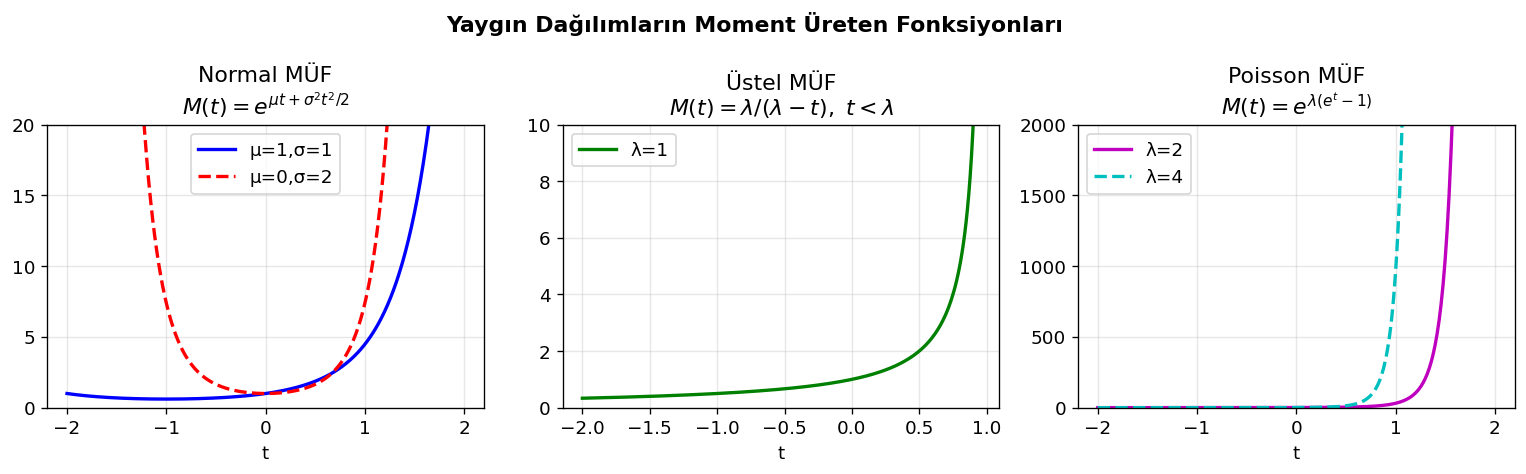

In [14]:
# ── MÜF — Yaygın Dağılımlar için Karşılaştırma ───────────────────────────────
t_vals = np.linspace(-2, 2, 400)

def muf_normal(t, mu=0, sigma=1):
    """X~Normal(μ,σ²): M(t) = exp(μt + σ²t²/2)"""
    return np.exp(mu * t + 0.5 * sigma**2 * t**2)

def muf_exp(t, lam=1):
    """X~Exp(λ): M(t) = λ/(λ-t), t<λ"""
    safe = np.where(t < lam, t, np.nan)
    return lam / (lam - safe)

def muf_poisson(t, lam=2):
    """X~Poisson(λ): M(t) = exp(λ(eᵗ-1))"""
    return np.exp(lam * (np.exp(t) - 1))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].plot(t_vals, muf_normal(t_vals, 1, 1), 'b-', lw=2)
axes[0].plot(t_vals, muf_normal(t_vals, 0, 2), 'r--', lw=2, label='σ=2')
axes[0].set_ylim(0, 20); axes[0].set_title('Normal MÜF\n$M(t)=e^{\\mu t+\\sigma^2 t^2/2}$')
axes[0].set_xlabel('t'); axes[0].legend(['μ=1,σ=1', 'μ=0,σ=2'])

t_exp = t_vals[t_vals < 0.95]
axes[1].plot(t_exp, muf_exp(t_exp, lam=1), 'g-', lw=2)
axes[1].set_ylim(0, 10); axes[1].set_title('Üstel MÜF\n$M(t)=\\lambda/(\\lambda-t), t<\\lambda$')
axes[1].set_xlabel('t'); axes[1].legend(['λ=1'])

axes[2].plot(t_vals, muf_poisson(t_vals, 2), 'm-', lw=2)
axes[2].plot(t_vals, muf_poisson(t_vals, 4), 'c--', lw=2)
axes[2].set_ylim(0, 2000); axes[2].set_title('Poisson MÜF\n$M(t)=e^{\\lambda(e^t-1)}$')
axes[2].set_xlabel('t'); axes[2].legend(['λ=2', 'λ=4'])

plt.suptitle('Yaygın Dağılımların Moment Üreten Fonksiyonları', fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# ── MÜF Özellik 1: Bağımsız toplamın MÜF'ü = MÜF'lerin çarpımı ──────────────
# X ~ Normal(μ₁,σ₁²),  Y ~ Normal(μ₂,σ₂²)  bağımsız
# X+Y ~ Normal(μ₁+μ₂, σ₁²+σ₂²)

mu1, sig1 = 2, 1
mu2, sig2 = 3, 2
t0 = 0.5   # t noktasında değerlendirme

M_X   = muf_normal(t0, mu1, sig1)
M_Y   = muf_normal(t0, mu2, sig2)
M_XpY_carpim = M_X * M_Y
M_XpY_direkt = muf_normal(t0, mu1+mu2, np.sqrt(sig1**2+sig2**2))

print("MÜF Özellik 1: M_{X+Y}(t) = M_X(t) · M_Y(t)")
print("═" * 48)
print(f"  X ~ Normal({mu1},{sig1}²),  Y ~ Normal({mu2},{sig2}²)")
print(f"  t = {t0}")
print(f"  M_X({t0})              = {M_X:.6f}")
print(f"  M_Y({t0})              = {M_Y:.6f}")
print(f"  M_X · M_Y             = {M_XpY_carpim:.6f}")
print(f"  M_{{X+Y}}({t0}) [direkt] = {M_XpY_direkt:.6f}")
print(f"  Eşit mi? {'✓ Evet' if np.isclose(M_XpY_carpim, M_XpY_direkt) else '✗ Hayır'}")

MÜF Özellik 1: M_{X+Y}(t) = M_X(t) · M_Y(t)
════════════════════════════════════════════════
  X ~ Normal(2,1²),  Y ~ Normal(3,2²)
  t = 0.5
  M_X(0.5)              = 3.080217
  M_Y(0.5)              = 7.389056
  M_X · M_Y             = 22.759895
  M_{X+Y}(0.5) [direkt] = 22.759895
  Eşit mi? ✓ Evet


---
## 9 · Özet: Tüm Özellikler Bir Arada

In [16]:
ozet = """
╔══════════════════════════════════════════════════════════════════════════════╗
║          Bölüm 7 — Beklenen Değerin Özellikleri: Özet Tablosu              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║ Özellik                │ Formül                                             ║
╠══════════════════════════════════════════════════════════════════════════════╣
║ Doğrusallık            │ E[X₁+⋯+Xₙ] = E[X₁]+⋯+E[Xₙ]  (her zaman)       ║
║ Çarpım (bağımsızlık)   │ E[XY] = E[X]·E[Y]  (X⊥Y ise)                    ║
║ Kovaryans def.         │ Cov(X,Y) = E[XY] − E[X]E[Y]                      ║
║ Toplam varyansı        │ Var(X+Y) = Var(X)+Var(Y)+2Cov(X,Y)               ║
║ Korelasyon             │ ρ(X,Y) = Cov(X,Y)/[σ_X · σ_Y] ∈ [−1,1]         ║
║ Bağımsızlık →          │ Cov(X,Y) = 0  (ama tersi doğru DEĞİL)            ║
║ İterasyon yasası       │ E[X] = E[E[X|Y]]                                  ║
║ Toplam varyans yasası  │ Var(X) = E[Var(X|Y)] + Var(E[X|Y])               ║
║ MÜF tanımı             │ M(t) = E[eᵗˣ]                                     ║
║ MÜF momentler          │ M⁽ⁿ⁾(0) = E[Xⁿ]                                  ║
║ MÜF bağımsız toplam    │ M_{X+Y}(t) = M_X(t)·M_Y(t)                       ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""
print(ozet)


╔══════════════════════════════════════════════════════════════════════════════╗
║          Bölüm 7 — Beklenen Değerin Özellikleri: Özet Tablosu              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║ Özellik                │ Formül                                             ║
╠══════════════════════════════════════════════════════════════════════════════╣
║ Doğrusallık            │ E[X₁+⋯+Xₙ] = E[X₁]+⋯+E[Xₙ]  (her zaman)       ║
║ Çarpım (bağımsızlık)   │ E[XY] = E[X]·E[Y]  (X⊥Y ise)                    ║
║ Kovaryans def.         │ Cov(X,Y) = E[XY] − E[X]E[Y]                      ║
║ Toplam varyansı        │ Var(X+Y) = Var(X)+Var(Y)+2Cov(X,Y)               ║
║ Korelasyon             │ ρ(X,Y) = Cov(X,Y)/[σ_X · σ_Y] ∈ [−1,1]         ║
║ Bağımsızlık →          │ Cov(X,Y) = 0  (ama tersi doğru DEĞİL)            ║
║ İterasyon yasası       │ E[X] = E[E[X|Y]]                                  ║
║ Toplam varyans yasası  │ Var(X) = E[Var(X|Y)] + Var(E[

---
## 10 · Alıştırmalar

1. $X \sim \text{Uniform}(0,1)$, $Y = X^3$ için $\text{Cov}(X,Y)$ ve $\rho(X,Y)$'yi hem analitik hem de Monte Carlo ile hesaplayın.

2. Bir öğrencinin her ders için bağımsız olarak 1 ile 5 puan arasında uniform not aldığı 10 dersten oluşan bir programda toplam puanın beklenen değeri ve varyansını MÜF kullanarak bulun.

3. Madenci problemini 4 kapıya genelleştirin: kapı 4, madenciye 9 saatte geri döndürsün. $E[X]$'i analitik ve simülasyonla bulun.

4. $X \sim \text{Normal}(0,1)$ için $M(t)=e^{t^2/2}$ olduğunu gösterin ve $M''(0) = E[X^2] = 1$ olduğunu doğrulayın.